# Homework 1

### Movies imdb dataset 

First step: Import the libraries for data manipulation (Panda) and data visualization (Matplotlib and seaborn)

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


Load the data from the csv file and get initial information about the dataset configuration

In [146]:
df = pd.read_csv('https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv')
df.head()
df.info()

df.describe()
df.isna().sum()



<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 125.1 KB


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

 Start the data cleaning proccess with the 2 strategies, median for the numerical columns and mode for other columns. Also transform some columns from string to float in order to make the cleaning easier


In [147]:
df["Runtime"] = df["Runtime"].str.replace(' min', '').astype(int)

df['Gross'] = df['Gross'].str.replace(',', '').astype(float)

df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

for col in ['Gross', 'Meta_score', 'Released_Year']:
    df[col] = df[col].fillna(df[col].median())

df['Certificate'] = df['Certificate'].fillna(df['Certificate'].mode()[0])

#remove the extreme high values from gross column and keep the one that statistically are between first and third quartile
Q1 = df['Gross'].quantile(0.25)
Q3 = df['Gross'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['Gross'] = np.where(df['Gross'] > upper_bound, upper_bound, df['Gross'])


# show the dataset configurations after the cleaning process
df.info()




<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   float64
 3   Certificate    1000 non-null   str    
 4   Runtime        1000 non-null   int64  
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   float64
dtypes: float64(4), int64(2), str(10)
memory usage: 125.1 KB


##### Data Transformation
- encode some columns with different techniques and perform feature scaling

In [ ]:
#give me the numerical columns of the dataset
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols

min_max_cols = ['Gross', 'Meta_score', 'Released_Year']
scaler = MinMaxScaler()
df_transformed = df.copy()
df_transformed[min_max_cols] = scaler.fit_transform(df_transformed[min_max_cols])

normalized_cols = ['Released_Year', 'No_of_Votes', 'IMDB_Rating', 'Runtime']

scaler = MinMaxScaler()
df_transformed[normalized_cols] = scaler.fit_transform(df_transformed[normalized_cols])

df_transformed.head(10)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,0.74,A,0.351449,Drama,1.000000,Two imprisoned men bond over a number of years...,0.722222,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,1.000000,0.193674
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,0.52,A,0.471014,"Crime, Drama",0.941176,An organized crime dynasty's aging patriarch t...,1.000000,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,0.688207,0.922340
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,0.88,UA,0.387681,"Action, Crime, Drama",0.823529,When the menace known as the Joker wreaks havo...,0.777778,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,0.982797,1.000000
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,0.54,A,0.568841,"Crime, Drama",0.823529,The early life and career of Vito Corleone in ...,0.861111,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,0.476641,0.391574
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,0.37,U,0.184783,"Crime, Drama",0.823529,A jury holdout attempts to prevent a miscarria...,0.944444,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,0.286778,0.029787
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,0.83,U,0.565217,"Action, Adventure, Drama",0.764706,Gandalf and Aragorn lead the World of Men agai...,0.916667,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,0.697867,1.000000
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,0.74,A,0.394928,"Crime, Drama",0.764706,"The lives of two mob hitmen, a boxer, a gangst...",0.916667,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,0.776999,0.737567
7,https://m.media-amazon.com/images/M/MV5BNDE4OT...,Schindler's List,0.73,A,0.543478,"Biography, Drama, History",0.764706,"In German-occupied Poland during World War II,...",0.916667,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,0.512686,0.662189
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,0.90,UA,0.373188,"Action, Adventure, Sci-Fi",0.705882,A thief who steals corporate secrets through t...,0.638889,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,0.880904,1.000000
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,0.79,A,0.340580,Drama,0.705882,An insomniac office worker and a devil-may-car...,0.527778,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,0.789316,0.253052


After normalization and minmax scaling for numerical columns, I will proceed by applying encoding on the categorical columns 

In [ ]:
label_encoded_col = 'Certificate'
df_transformed[label_encoded_col] = df_transformed[label_encoded_col].astype('category').cat.codes

genre_dummies = df_transformed['Genre'].str.get_dummies(sep=', ')
genre_dummies = genre_dummies.add_prefix('Genre_')
df_transformed = pd.concat([df_transformed, genre_dummies], axis=1)
df_transformed.drop('Genre', axis=1, inplace=True)

genre_columns = [col for col in df_transformed.columns if col.startswith('Genre_')]
df_transformed[genre_columns].head(10)


,Genre_Action,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,Genre_Crime,Genre_Drama,Genre_Family,Genre_Fantasy,Genre_Film-Noir,...,Genre_Horror,Genre_Music,Genre_Musical,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_War,Genre_Western
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
9,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Data Reduction - drop some useless columns and reduce 4 numerical columns to 2, I removed Poster_Link and Overview because they are unique text identifiers/URLs that hold no mathematical value for distance-based algorithms. I then applied Principal Component Analysis (PCA) to compress the remaining numerical features.

Performance: Dropping irrelevant columns and reducing dimensions lowers memory usage and speeds up computational time

Interpretability: By squishing 4 dimensions down into 2 principal components (PCA_1 and PCA_2), we can now easily plot and visualize the variance of our complex dataset 

    

    

In [150]:
columns_to_drop = ['Poster_Link', 'Overview']
df_reduced = df_transformed.drop(columns=columns_to_drop, errors='ignore')

pca = PCA(n_components=2)

num_features = ["IMDB_Rating", "Meta_score", "No_of_Votes", "Gross"]

pca_result = pca.fit_transform(df_reduced[num_features].fillna(0))

df_reduced['PCA_1'] = pca_result[:, 0]
df_reduced['PCA_2'] = pca_result[:, 1]

df_reduced.head(10)

,Series_Title,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,...,Genre_Musical,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_War,Genre_Western,PCA_1,PCA_2
0,The Shawshank Redemption,0.74,1,0.351449,1.000000,0.722222,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,...,0,0,0,0,0,0,0,0,0.192224,0.930015
1,The Godfather,0.52,1,0.471014,0.941176,1.000000,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,...,0,0,0,0,0,0,0,0,0.786395,0.847348
2,The Dark Knight,0.88,14,0.387681,0.823529,0.777778,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,...,0,0,0,0,0,0,0,0,0.946819,0.724860
3,The Godfather: Part II,0.54,1,0.568841,0.823529,0.861111,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,...,0,0,0,0,0,0,0,0,0.218715,0.674743
4,12 Angry Men,0.37,12,0.184783,0.823529,0.944444,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,...,0,0,0,0,0,0,0,0,-0.184593,0.699126
5,The Lord of the Rings: The Return of the King,0.83,12,0.565217,0.764706,0.916667,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,...,0,0,0,0,0,0,0,0,0.857341,0.660826
6,Pulp Fiction,0.74,1,0.394928,0.764706,0.916667,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,...,0,0,0,0,0,0,0,0,0.628348,0.716832
7,Schindler's List,0.73,1,0.543478,0.764706,0.916667,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,...,0,0,0,0,0,0,0,0,0.482056,0.639504
8,Inception,0.90,14,0.373188,0.705882,0.638889,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,...,0,0,0,1,0,0,0,0,0.917931,0.526760
9,Fight Club,0.79,1,0.340580,0.705882,0.527778,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,...,0,0,0,0,0,0,0,0,0.182302,0.523774


Feature enginnering - created a heat map to see what numerical columns correlate to each other, if their values are proportional or not.

I also created a new column called Revenue per vote, which shows the revenue per person (financial efficiency per person who voted)

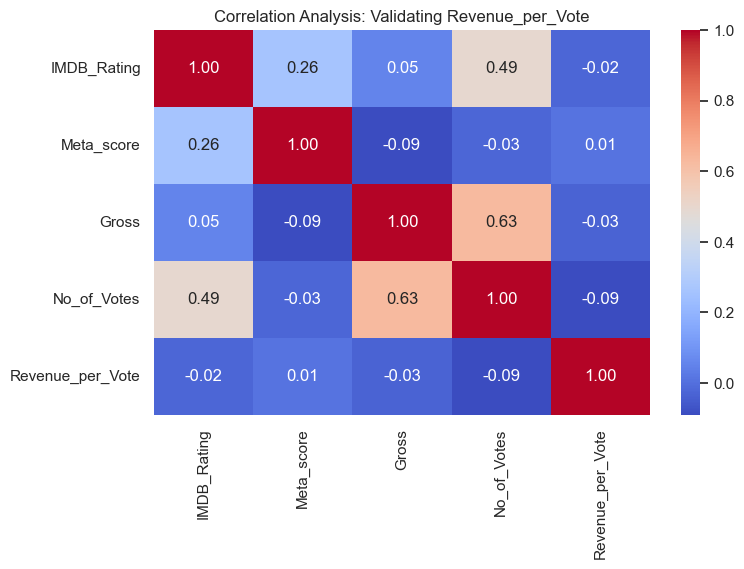

In [151]:
df_reduced['Revenue_per_Vote'] = df_reduced['Gross'] / (df_reduced['No_of_Votes'] + 1e-5)

cols_for_corr = ['IMDB_Rating', 'Meta_score', 'Gross', 'No_of_Votes', 'Revenue_per_Vote']
correlation_matrix = df_reduced[cols_for_corr].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Analysis: Validating Revenue_per_Vote")
plt.show()

1. Distribution of IMDB Ratings

What it shows: This plot displays the frequency of different IMDB ratings across the Top 1000 movies.

Why I chose this plot: A histogram with a Kernel Density Estimate (KDE) curve is the most effective way to visualize the distribution, central tendency, and skewness of a single continuous variable.

Insight: IMDb users give good to very  goog ratings at every movie. The lowest rating on this "Top 1000" list is still a massive 7.6. 

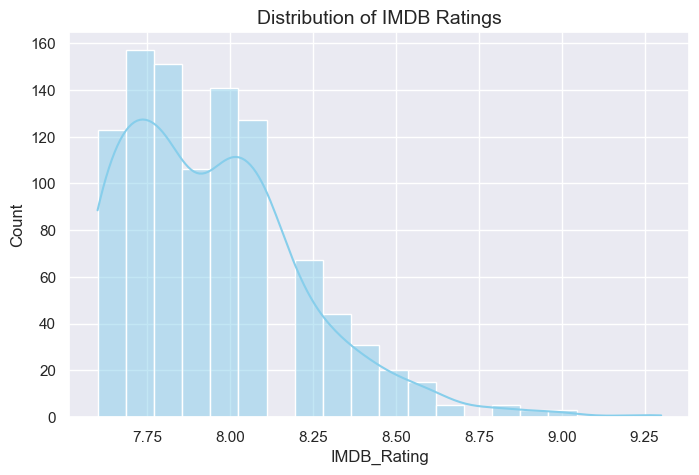

In [152]:
plt.figure(figsize=(8, 5))
sns.histplot(df['IMDB_Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of IMDB Ratings', fontsize=14)
plt.show()

2. Movie Runtimes

What it shows: The spread of movie runtimes, highlighting the median length and extreme outliers.

Why I chose this plot: A boxplot is the standard statistical visualization for identifying anomalies and outliers in a dataset

Insight: There are 147 movies with a runtine bigger than the median, one of them being 321 minutes

147
Median Runtime: 119.0 minutes


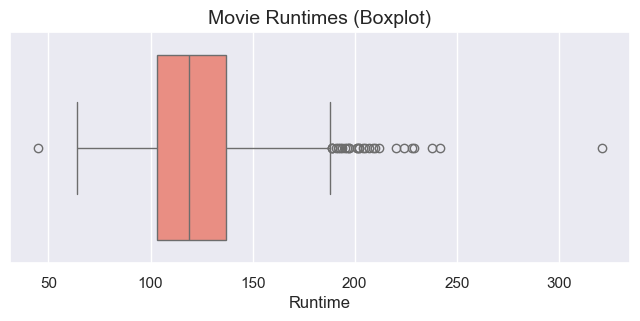

In [153]:
movies_longer_than_150 = df[df['Runtime'] > 150]
print(len(movies_longer_than_150))


median_runtime = df['Runtime'].median()
print(f"Median Runtime: {median_runtime} minutes")

plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Runtime'], color='salmon')
plt.title('Movie Runtimes (Boxplot)', fontsize=14)
plt.show()



3. Movie Revenue+Popularity plot

What it shows: The connection and the proprortion between the movie popularity(no of votes) and the revenue from them(gross). 

Why I chose this plot: It is clearly to see that this not every popular movie has a large revenue, but also some movies revenues are linked to the number of votes from the fans.

Insight: If a movie has a lot of votes it is almost certanly that the money revenue will be high

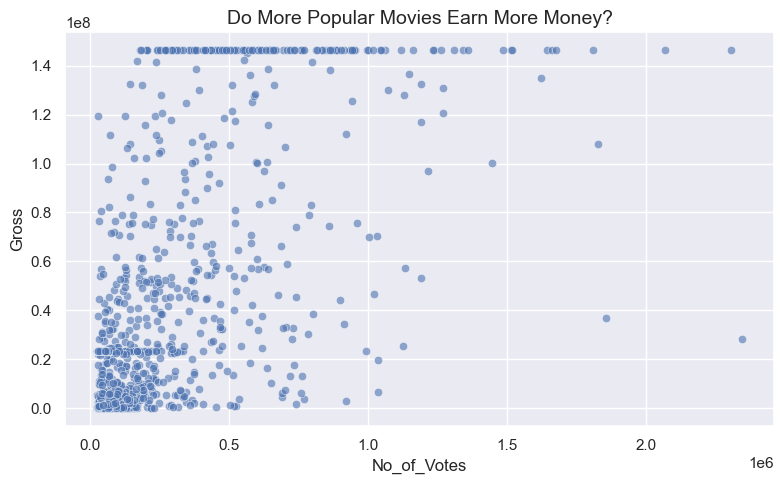

In [154]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='No_of_Votes', y='Gross', data=df, alpha=0.6)
plt.title('Do More Popular Movies Earn More Money?', fontsize=14)
plt.tight_layout()
plt.show()

4. Critics vs. Regular Audiences

What it shows: How professional critic scores (Meta_score) compare to regular audience scores (IMDB_Rating).

Why I chose this plot: A scatter plot allows us to compare two competing scoring systems on the same X/Y plane to find informations.

Insight: Professional critics are more drastic than a regular viewer. 

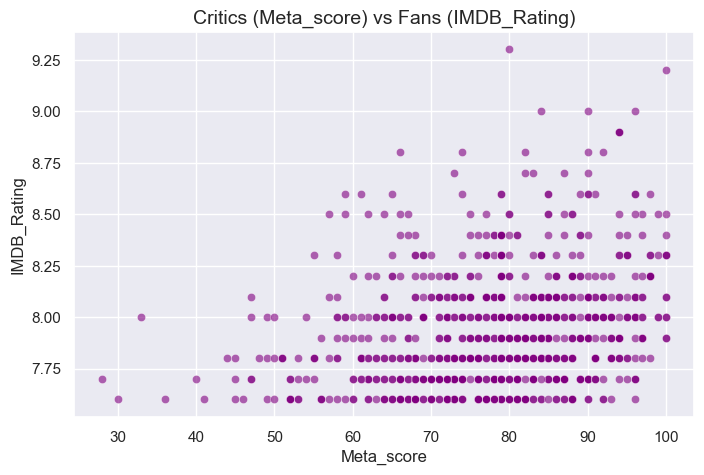

In [156]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Meta_score', y='IMDB_Rating', data=df, color='purple', alpha=0.6)
plt.title('Critics (Meta_score) vs Fans (IMDB_Rating)', fontsize=14)
plt.show()

5. Directors with the Most Top 1000 Movies

What it shows: The top 10 most frequently occurring directors in our dataset.

Why I chose this plot: A horizontal bar chart is ideal for displaying categorical frequency data, especially when the categories are long text names that would overlap on a vertical axis.

Insight: Some directors have already succes because of their name and credibility created with some bangers back in the days

C:\Users\Admin\AppData\Local\Temp\ipykernel_27920\1673482794.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')


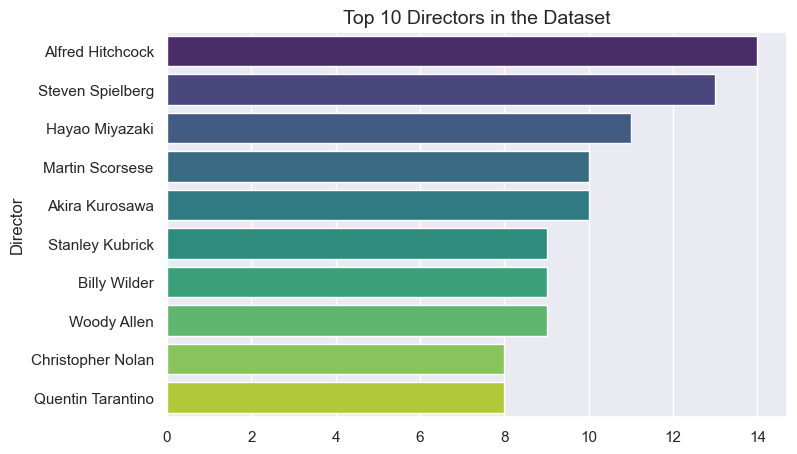

In [159]:
plt.figure(figsize=(8, 5))
top_directors = df['Director'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')
plt.title('Top 10 Directors in the Dataset', fontsize=14)
plt.show()

6. Leading Stars of the Top 1000

What it shows: The top 10 most frequently occurring lead actors (Star1).

Why I chose this plot: Similar to directors, a horizontal bar chart effectively ranks text-based categorical data from highest to lowest frequency.

Insight: This is the same reason as for directors plot, nowadays good actors and popular actors receive lead roles in movies to increase their popularity and income 

C:\Users\Admin\AppData\Local\Temp\ipykernel_27920\1335894006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_stars.values, y=top_stars.index, palette='magma')
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26 () missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


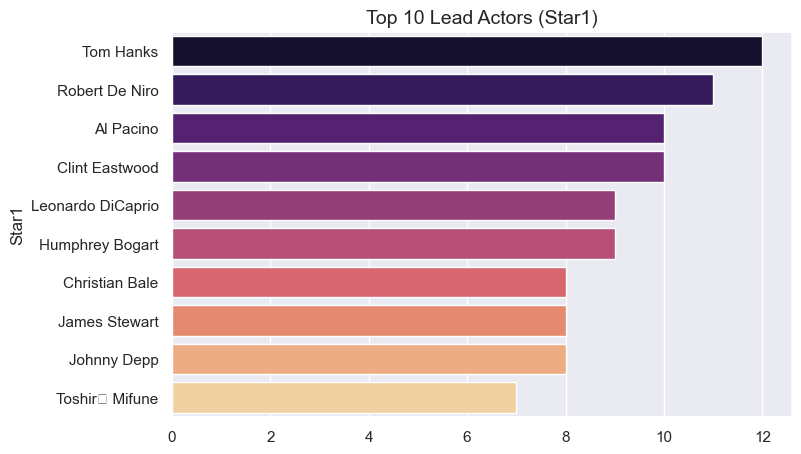

In [160]:
plt.figure(figsize=(8, 5))
top_stars = df['Star1'].value_counts().head(10)
sns.barplot(x=top_stars.values, y=top_stars.index, palette='magma')
plt.title('Top 10 Lead Actors (Star1)', fontsize=14)
plt.show()

7. The Mathematical Movie Map (PCA)

What it shows: Our entire numerical dataset compressed into two dimensions.

Why I chose this plot: A 2D scatter plot is the only way to visualize the results of our Dimensionality Reduction (PCA), allowing us to see how the mathematical algorithm clusters similar movies together.

Insight: The 2 new columns and values created are correct computed because the movies with similar rating are in the same spot on the graph 

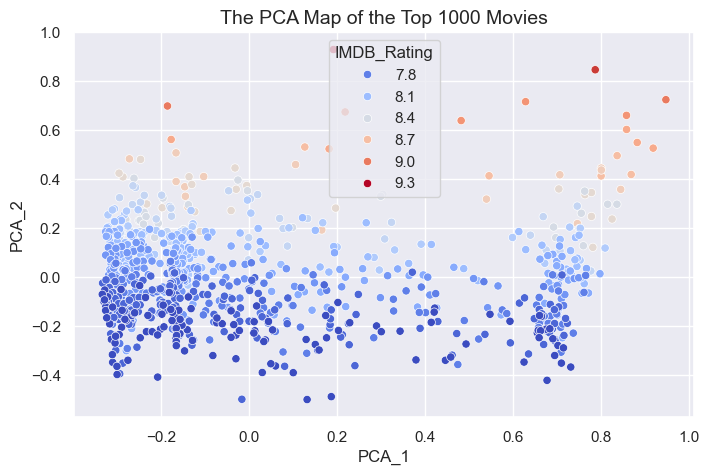

In [164]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='PCA_1', y='PCA_2', data=df_reduced, hue=df['IMDB_Rating'], palette='coolwarm')
plt.title('The PCA Map of the Top 1000 Movies', fontsize=14)
plt.show()

8. Financial Efficiency vs Quality

What it shows: The new feature (Revenue_per_Vote) compared against the movie's rating.

Why I chose this plot: A scatter plot is necessary to validate feature engineering, proving whether our new metric has a distinct relationship with the target variable.

Insight: Some of the lowest-rated movies on this list made the highest amount of money per fan vote, this is strange but shows how the proper marketing before the movie ranting released made people to buy in order to watch that movie.

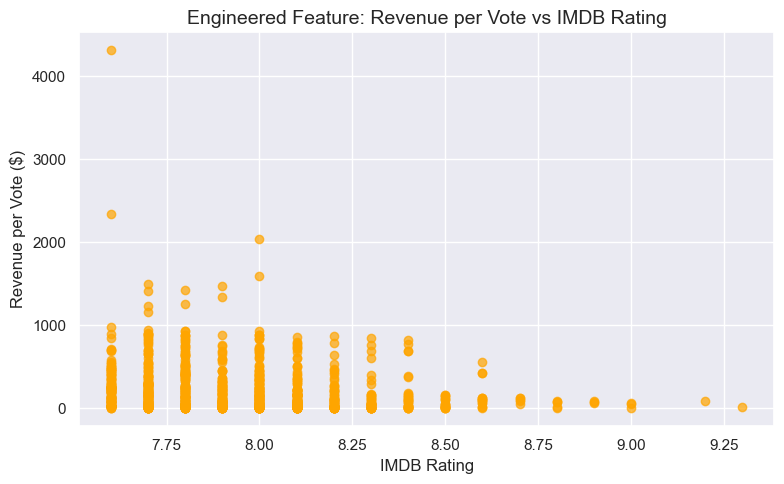

Movie with the highest Revenue per Vote:
Series_Title        On Golden Pond
Revenue_per_Vote       4313.964486
Name: 981, dtype: object


In [ ]:
# Use original values so Y axis shows real $/vote
revenue_per_vote_original = df['Gross'] / (df['No_of_Votes'] + 1)

plt.figure(figsize=(8, 5))
plt.scatter(df['IMDB_Rating'], revenue_per_vote_original, color='orange', alpha=0.7)
plt.xlabel('IMDB Rating', fontsize=12)
plt.ylabel('Revenue per Vote ($)', fontsize=12)
plt.title('Engineered Feature: Revenue per Vote vs IMDB Rating', fontsize=14)
plt.tight_layout()
plt.show()



9. Top 10 genres in the top 1000 movies dataset

What it shows: what are the most common genres between the top 1000 movies

Why I chose this plot: a horizontal bar chart is simple to understand and shows exactly what we need to see

Insight: A lot of movies have drama as a genre because every good story has some drama in order to spice the things up

C:\Users\Admin\AppData\Local\Temp\ipykernel_27920\788096826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Set2')


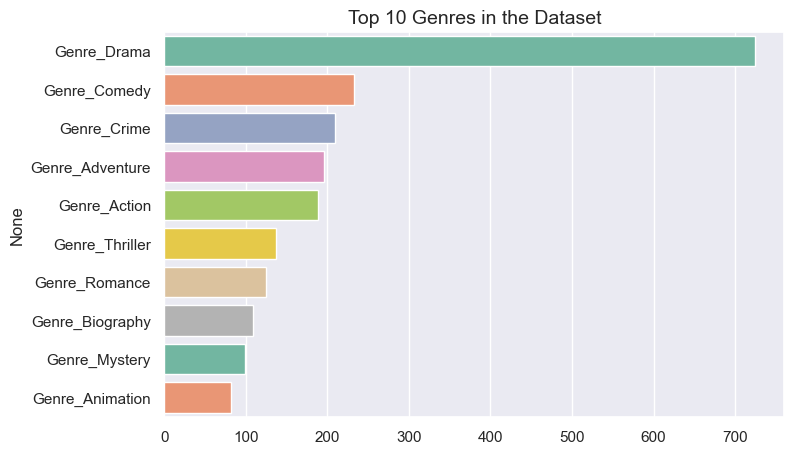

In [ ]:
plt.figure(figsize=(8, 5))
genre_cols = [col for col in df_reduced.columns if col.startswith('Genre_')]
genre_counts = df_reduced[genre_cols].sum().sort_values(ascending=False).head(10)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Set2')
plt.title('Top 10 Genres in the Dataset', fontsize=14)
plt.show()



## Movie recommandation system 

In [187]:
text_columns = df_reduced.select_dtypes(include=['object']).columns
numerical_df = df_reduced.drop(columns=text_columns, errors='ignore')

numerical_df = numerical_df.fillna(0)

cosine_matrix = cosine_similarity(numerical_df)


def getRecommandation(movie_title, top=5):
    if movie_title not in df_reduced['Series_Title'].values:
        print(f"Movie '{movie_title}' not found in the dataset.")
        return []
    
    movie_index = df_reduced[df_reduced['Series_Title'] == movie_title].index[0]
    similarity_scores = cosine_matrix[movie_index]

    similarity_scores = sorted(enumerate(similarity_scores), key=lambda x: x[1], reverse=True)

    top_movies = []

    for index, score in similarity_scores[1:top+1]:  
        top_movies.append((df_reduced.iloc[index]['Series_Title'], score))
    
    
    recommended_movies = [movie[0] for movie in top_movies]
    return recommended_movies


# Example usage:
movie_to_recommend = "The Godfather: Part II"
recommendations = getRecommandation(movie_to_recommend, top=5)
print(f"Recommended movies for '{movie_to_recommend}':")
for movie in recommendations:
    print(f"- {movie}")

movie_to_recommend2 = "The Shawshank Redemption"
recommendations2 = getRecommandation(movie_to_recommend2, top=5)
print(f"Recommended movies for '{movie_to_recommend2}':")
for movie in recommendations2:
    print(f"- {movie}")

Recommended movies for 'The Godfather: Part II':
- Pulp Fiction
- Taxi Driver
- The Godfather
- Scarface
- Cidade de Deus
Recommended movies for 'The Shawshank Redemption':
- Fight Club
- Requiem for a Dream
- The Godfather: Part II
- Pulp Fiction
- Trainspotting


C:\Users\Admin\AppData\Local\Temp\ipykernel_27920\2956676183.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df_reduced.select_dtypes(include=['object']).columns
